## O que é visão computacional

Visao computacional é um campo da IA que capacita as máquinas a intepretar e entender o mundo visual a partir de imagens e videos. O objetivo é replicar a capacidade humana de reconhecer objetos,cenas e extrair informaçoes 

Tambem tem correlaçao direta com os outros campos:
- Processamento de imagens : transformaçoes de imagem para melhorar qualidade ou extrair características

- Machine learning : algoritmos que aprendem a partir de dados visuais

- Deep Learning : CNN (rede neural convolucional) que revolucionaram essa área

### Aplicaçoes
| **Área**        | **Exemplos**                                             |
|-----------------|----------------------------------------------------------|
| **Saúde**       | Diagnóstico por imagem (raios-X, tomografias), detecção de tumores |
| **Automotiva**  | Carros autônomos, detecção de pedestres, leitura de placas |
| **Segurança**   | Reconhecimento facial, vigilância por vídeo              |
| **Varejo**      | Checkout automático, análise de comportamento do cliente |
| **Agricultura** | Monitoramento de plantações, detecção de pragas          |
| **Indústria**   | Inspeção de qualidade, robótica                          |

### Desafios: 
- Variabilidade intraclasse : Um mesmo objeto pode ter aparencias muito diferentes

-Condiçoes de luminaçao : sombras, reflexos

-Oclusoes : Objetos parcialmente escondidos

-Escala e rotaçao : Objtos podem aparecer em diferentes tamanhos e orientaçoes

-Background complexo : fundo confuso pode atrapalhar a detecçao




## Processamento de imagens com OpenCV

É a biblioteca mais popular para visao computacional. Possui diversos algoritmos 

In [2]:
# Instalação (uma vez por ambiente/kernel)
%pip install -q opencv-python matplotlib numpy

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.16.2 requires numpy<2.0.0,>=1.23.5; python_version <= "3.11", but you have numpy 2.4.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install --upgrade pip

### Vamos agora ver alguns comandos báscios da OpenCV

**Leitura e exibiçao de imagem :**

- cv2.imread() : Le as imagens em formato BGR

depois aplicamos 

- cv2.cvtColor() : Convertar as imagens de BGR -> RGB

Dimensões da imagem: (512, 512, 3)


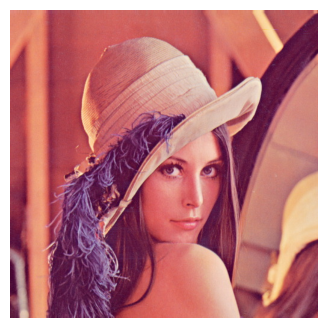

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Carregar uma imagem
!wget -q -O image.jpg https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg

# Lendo a imagem (OpenCV lê em BGR)
img = cv2.imread('image.jpg')
print("Dimensões da imagem:", img.shape)

# Mostrar a imagem (converter BGR -> RGB para o matplotlib)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(4,4))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

**Redimensionamento :**

É uma tarefa comum, especialemnte nas CNN`s, onde as imagens podem ser redimensionadas para um tamanho específico

- Interpolaçao : 
O OpenCV usa diferentes metodos de interpolaçao para redimensionar imagens:

*cv2_INTER_LINEAR :* Interpolaçao bilinear, boa para redimensionamento movel

*cv2.INTER_CUBIC :* Interpolaçao cubica, produz melhores resultados, mas mais lenta.

*cv2.INTER_NEAREST :* Interpolaçao mais rápida, mas com resultados mais precisos.



(224, 224, 3)


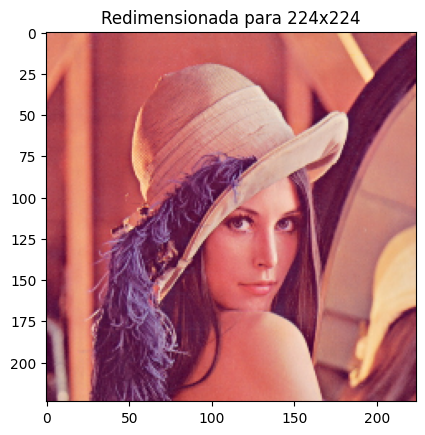

In [5]:
# Redimensionar para 224x224 (tamanho comum para CNNs)
img_resized = cv2.resize(img_rgb, (224, 224))

# Exibir a imagem redimensionada
print(img_resized.shape)
plt.imshow(img_resized)
plt.title('Redimensionada para 224x224')
plt.show()

**Normalizaçao :**

Normalizaçao / padronizaçao :

- Normalizaçao : Como opencv le valores de pixel no intervalo de 0 até 255, normalizando os valores no intervalo entre [0,1]

- Padronizaçao : Geramente padronizamos as imagens subtraindo a media e dividindo pelo desvio padrao. Isso ajuda a convergencia de treinamento do modelo e a performance do modelo.

In [6]:
# Normalização simples: dividir por 255
img_norm = img_rgb / 255.0
print("Valores após normalização:", img_norm.min(), img_norm.max())

# Padronização (subtrair média e dividir por desvio) - útil para CNNs pré-treinadas
mean = [0.485, 0.456, 0.406]  # médias do ImageNet
std = [0.229, 0.224, 0.225]   # desvios do ImageNet
img_std = (img_norm - mean) / std

print("Valores após padronização:", img_std.min(), img_std.max())

Valores após normalização: 0.0 1.0
Valores após padronização: -2.0357142857142856 2.271008403361344


**Conversao de cores :**

- Rbg para escala cinza (Grayscale): A escala de cinza é muito usada em visao computacional, como detecçao de bordas ou simplificaçao de imagem

- RGB para HSV : HSV é um pouco mais intuitiva para tarefas de segmentaçao de cores, pois separa em cor e intensidade. Facilitando tarefas como segmentaçao de objetos de uma cor especifica

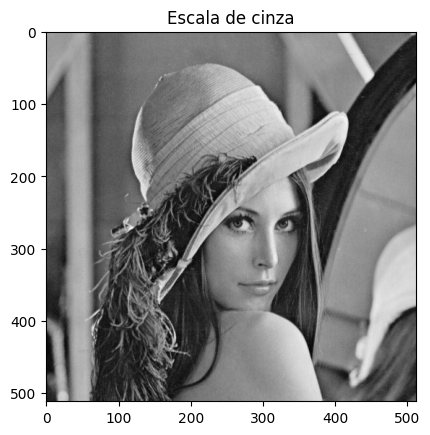

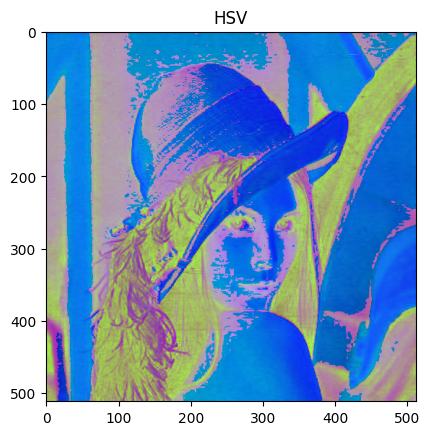

In [7]:
# RGB para escala de cinza
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
plt.imshow(img_gray, cmap='gray')
plt.title('Escala de cinza')
plt.show()

# RGB para HSV (Hue, Saturation, Value)
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
plt.imshow(img_hsv)
plt.title('HSV')
plt.show()

## Operaçoes básicas de efeito

**Borramento(Gaussian Blur) :** Utilizado para suavizar a imagem, removendo ruidos. A operaçao é muito usada no preprocessamento das imagens e em tecnicas de detecçao de bordas.

**Thresholding binário :** Converte uma imagem para uma imagem de dois valores (0,1). Definimos um limiar, se o valor for acima do limiar 1, se for menor 0.Muito utilizando tambem para separar objetos no fundi baseado na intensidade do pixel.

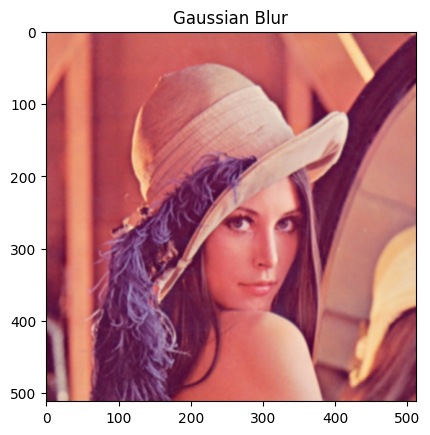

In [8]:
# Borramento (Gaussian Blur)
img_blur = cv2.GaussianBlur(img_rgb, (5,5), 0)
plt.imshow(img_blur)
plt.title('Gaussian Blur')
plt.show()

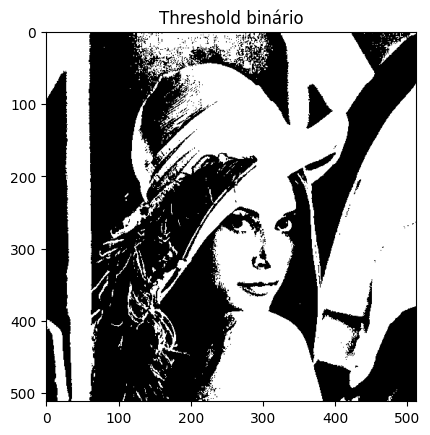

In [9]:
# Thresholding binário (na imagem em cinza)
_, img_thresh = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)
plt.imshow(img_thresh, cmap='gray')
plt.title('Threshold binário')
plt.show()

**Detecçao de bordas usando canny**

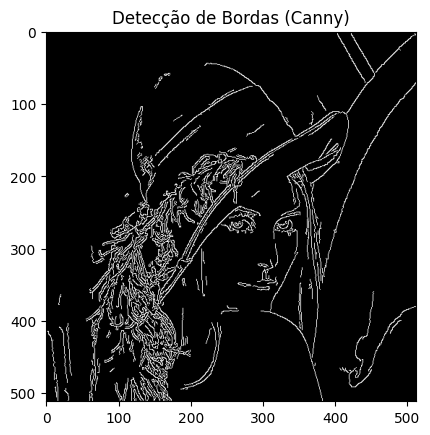

In [10]:
img_canny = cv2.Canny(img_gray, 100, 200)
plt.imshow(img_canny, cmap='gray')
plt.title('Detecção de Bordas (Canny)')
plt.show()

Transformaçoes geometricas :Transformaçoes em perspectiva, como rotaçao, translaçao e shearing 

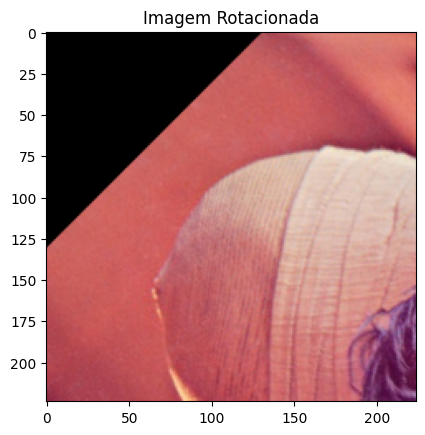

In [11]:
M = cv2.getRotationMatrix2D((224, 224), 45, 1)
img_rotated = cv2.warpAffine(img_rgb, M, (224, 224))
plt.imshow(img_rotated)
plt.title('Imagem Rotacionada')
plt.show()

## CNN (Rede neural convolucional)

Para algumas tarefas vamos usar uma cnn, e tudo tem um motivo. Pixels vizinhos costumam estar relacionados entre si e formam padroes como bordas, texturas, formas e objetos.

Por isso, usar uma rede neural totalmente conectadas para imagem nao é a melhor escolha.

Em uma rede densa, cada neuronio da primeira camada se conecta a todos os pixels da imagem, gerando um grande numero de parametros. Exp: Uma imagem de 224 x 224 x 3 possui : 150528 valores

Se a primeira camada tiver apenas 128 neuronios, ja seriam mais de 19 milhoes de pesos apenas nessa camad. Aumentando o custo computacional, risco de overfitting e ignora a organizaçao da imagem

Exemplo prático : Se quisermos classificar imagens de gatos e cachorros, uma rede totalmente conectada tentaria aprender pesos independentes para cada pixel. Já uma CNN. aprende filtros que identificam padroes visuais, como: bordas das orelhas, textura do pelo, formato dos olhos, contorno do focinho

Esses padroes podem aparecer em qualquer parte da imagem, e a CNN consegue reutilzar esse conhecimento.


### Camadas convolucionais

A camada convolucinal é o principal componente de uma CNN. Ela aplica pequenos filtros (kernels) sobre a imagem para detectar padroes locais.

Esses filtros deslizam pela imagem realiando uam operaçao chamada convoluçao, gerando um mapa de caracteristica (feature map)

Cada filtro aprende a detectar um padrao especifico: bordas verticais, horizontais, cantos, texturas e partes de objetios

EX: 
imagem de entrada -> Filtro 3x3 -> mapa de caracteristicas

Se usarmos 32 filtros, a camada ira produzir 32 mapas de caracteristicas diferentes, cada um destacando seu padrao.

**Parametros principais :**

- Filters : Numero de filtros aprendidos na camada

- Stride : Define quantos pixels o filtro avança a cada passo
    Stride = 1 : desloca pixel a pixel
           = 2 : pula pixels(reduz resoluçao)

- Padding : Define se adicionamos bordas na imagem
    Valid : sem padding, a imagem diminui
    same : padding aplicado para manter o tamanho

In [12]:
# Instalação do TensorFlow (rode **uma vez** por ambiente/kernel)
#
# macOS Intel (x86_64) + Python 3.11:
#   - Prefira versões fixas para evitar conflitos estranhos (ex: RecursionError no import)
#   - Se já estiver instalado e funcionando, pode pular esta célula.
%pip install -q --upgrade "numpy==1.26.4" "tensorflow==2.16.2" "keras==3.13.2" "ml-dtypes==0.3.2"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [13]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D

print('TensorFlow:', tf.__version__)

# camada convolucional (exemplo)
conv_layer = Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation='relu',
    input_shape=(224, 224, 3),
)


TensorFlow: 2.16.2


Exemplo simples de cnn. Ele tem como objetivo detectar bordas na imagem, algo que as primeiras camadas da cnn aprendem rapidamente

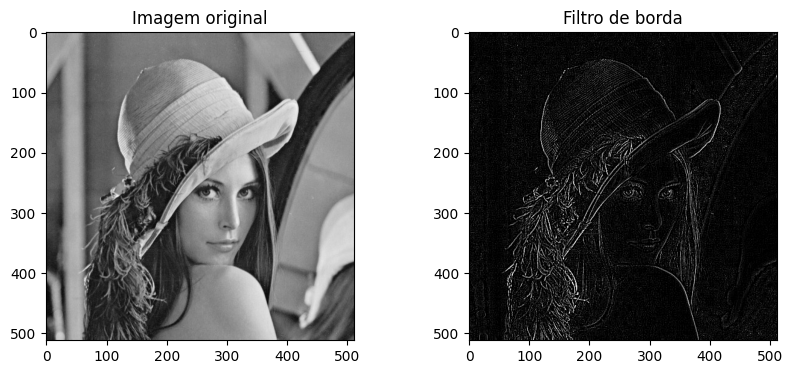

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("image.jpg",0)

# filtro simples de detecção de borda
kernel = np.array([
[-1,-1,-1],
[-1, 8,-1],
[-1,-1,-1]
])

filtered = cv2.filter2D(img,-1,kernel)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img,cmap="gray")
plt.title("Imagem original")

plt.subplot(1,2,2)
plt.imshow(filtered,cmap="gray")
plt.title("Filtro de borda")

plt.show()

### Pooling

Apos a convoluçao, normalmente aplicamos uma camada chamada pooling

O objetivo do pooling é:
- Reduzir o tamanho da imagem
- Reduzir custo computacional
- Tornar a rede mais robusta a pequenas variaçoes

Em vez de analisar cada pixel, a rede passa a analisar regioes resumidas


**TIPOS PRINCIPAIS :**

- MaxPooling : Seleciona o maior valor dentro da janela. \
Ex: matriz 

2 5
1 3 

Vamos estar pegando o 5

- AveragePooling : Calcula a media dos valores
Ex: Matriz
2 5
1 3

Resultado 2.75


In [15]:
#Reduzindo uma imagem pela metade
from tensorflow.keras.layers import MaxPooling2D

pool = MaxPooling2D(pool_size=(2,2))

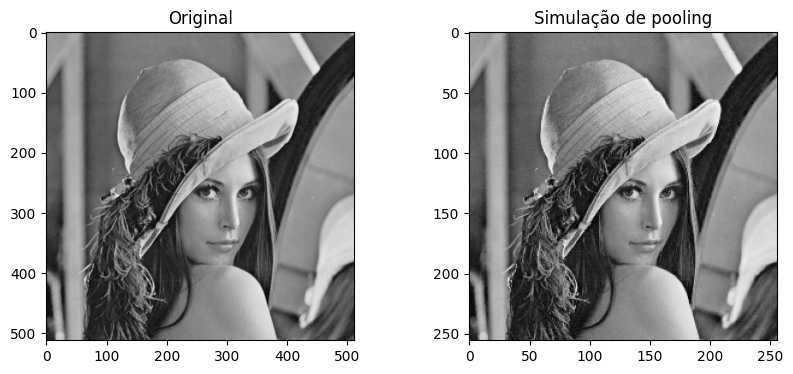

In [16]:
img = cv2.imread("image.jpg",0)

pool = img[::2, ::2]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img,cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(pool,cmap="gray")
plt.title("Simulação de pooling")

plt.show()

## Arquiteturas clássicas

| Arquitetura | Ano  | Características                                    |
| ----------- | ---- | -------------------------------------------------- |
| **LeNet-5** | 1998 | Primeira CNN famosa, usada para reconhecer dígitos |
| **AlexNet** | 2012 | Revolucionou o ImageNet, introduziu ReLU e GPUs    |
| **VGG**     | 2014 | Arquitetura simples usando muitos filtros 3×3      |
| **ResNet**  | 2015 | Introduziu conexões residuais (skip connections)   |


**LeNet-5 :** Desenvolvida para reconhecimento de digito. Muito usada para leitura de cheques em bancos

**AlexNet :** Marco no imageNet, com as principais ideias : uso massivo de GPU, ativação ReLU, dropout para regularização

**VGG :** Arquitetura simples e elegante, usando blocos de conv, conv, pooling repetidos (sempre 3x3)

**Resnet :** Resolve o problema de vanish gradient. Alem disso, ele introduz **skip connection**, logo, conseguimos treinar redes com mais de 100 camadas.

Vamos criar uma rede com esse fluxo:

Imagem

↓

Conv

↓

Pooling

↓

Conv

↓

Pooling

↓

Flatten

↓

Dense

↓

Classificação

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([

Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
MaxPooling2D(2,2),

Conv2D(64,(3,3),activation='relu'),
MaxPooling2D(2,2),

Flatten(),

Dense(128,activation='relu'),
Dense(10,activation='softmax')

])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,908,682 (91.20 MB)

 Trainable params: 23,908,682 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

## Transfer Learning 

### Conceito
Treinar CNN's do zero exige muito dado e muito poder computacional. Por isso, temos o transfer learning.

A ideia é reutilizar um modelo treinado em uma grande base de dados(ex: ImageNet, com mais de 14 milhoes de imagens)

As primeiras camadas aprendem padroes gerais como :
- bordas
- texturas
- cores
- formas simples

Sao padores uteis para praticamente todas as tarefas de visao computiacional

Exemplo : Um modelo treinado para reconhecer animais tambem aprende: contornos, texturas, padroes de luz.

Esses reconehcimentos podem ser reaproveitados para : detecção de doenças em plantas, classificação de objetos, inpesção industrial

### Estrategia

**Feature Extraction :** Congela as camadas da rede pré-treinada, treinando apenas a **parte final**.

CNN pré-treinada → congelada

↓

nova camada Dense

↓

nova tarefa

- Vantagens : rápido, funciona com pouco dado


**Fine-Tuning**
Descongela algumas camadas superiores e continua treinando. Isso permite que o modelo **se adapte melhor ao novo problema.**

Normalmente usamos um learning rate menor.

In [18]:
#Exemplo com tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
# Congelando as camadas
base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
predictions = layers.Dense(10, activation='softmax')(x)
model = models.Model(inputs=base_model.input, outputs=predictions)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
# Exemplo simples: passar um batch dummy pelo modelo de Transfer Learning (MobileNetV2) criado acima
# Usa: model, train_data, val_data, X_dummy (já existentes no notebook)

# 1) Rodar um forward pass (predição) com X_dummy
y_pred = model.predict(X_dummy, verbose=0)
print("Shape de entrada:", X_dummy.shape)
print("Shape da saída (pred):", y_pred.shape)
print("Primeira predição (vetor de 10 classes):\n", y_pred[0])

# 2) Compilar e treinar rapidinho com dados dummy que você já tem (train_data/val_data)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(
    train_data[0], train_data[1],
    validation_data=val_data,
    epochs=2,
    batch_size=8,
    verbose=1
)

# 3) Avaliar no conjunto de validação (dummy)
val_loss, val_acc = model.evaluate(val_data[0], val_data[1], verbose=0)
print(f"Val loss: {val_loss:.4f}  |  Val acc: {val_acc:.4f}")

Shape de entrada: (32, 224, 224, 3)
Shape da saída (pred): (32, 10)
Primeira predição (vetor de 10 classes):
 [0.1266726  0.2212148  0.11528981 0.00767543 0.24565297 0.02528867
 0.13130137 0.0504376  0.01223666 0.06422998]
Epoch 1/2
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.0312 - loss: 2.7646 - val_accuracy: 0.1875 - val_loss: 2.4327
Epoch 2/2
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.0312 - loss: 2.7646 - val_accuracy: 0.1875 - val_loss: 2.4327
Epoch 2/2
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 402ms/step - accuracy: 0.6562 - loss: 1.2526 - val_accuracy: 0.1250 - val_loss: 2.3471
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 402ms/step - accuracy: 0.6562 - loss: 1.2526 - val_accuracy: 0.1250 - val_loss: 2.3471
Val loss: 2.3471  |  Val acc: 0.1250
Val loss: 2.3471  |  Val acc: 0.1250


## Avaliaçao de modelos

Metricas para classifica;áo : Acuracia, precisao, recall, f1 score, matriz de confusao, curva roc

Metricas para detecçao e segmentaçao : IoU -> Mede quanto a bounding box prevista coincide com a real. 

IoU = Area da interseçao / antes da uniao

**mAP(mean average precision) :** Metrica padrao em detecçao de objetos. Calcula a média da precisao em diferentes limiares

**Curva precision recall :** Mostra o trade off entre precisao e recall. Ao variar o limiar de confiança do detector.

A área sob a curva é chamada Average Precision (AP)

## Roboflow

Roboflow é uma plataforma para gerenciar datasets de visao computacional. Facilitando : anotaçao de imagens, aumento de dados, exportaçao de datasets, conversao entre formatos


https://roboflow.com

In [25]:
!pip install ultralytics

In [26]:
#Vamos rodar um exemplo de codigo 
## importing required libraries
import os
import shutil
import random
!pip install tqdm --upgrade
from tqdm.notebook import tqdm
from IPython import display
display.clear_output()
from ultralytics import YOLO
from IPython.display import display, Image
import ultralytics
ultralytics.checks()

Ultralytics 8.4.21 🚀 Python-3.11.9 torch-2.2.2 CPU (Intel Core i5-1038NG7 2.00GHz)
Setup complete ✅ (8 CPUs, 32.0 GB RAM, 295.8/465.6 GB disk)
Setup complete ✅ (8 CPUs, 32.0 GB RAM, 295.8/465.6 GB disk)


In [29]:
from ultralytics import YOLO

from IPython.display import display, Image

In [31]:
%cd {HOME}
%mkdir {HOME}/datasets
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="aJO0DguOcxOKKsVf2mq5")
project = rf.workspace("alvaro-z5qmu").project("aws-ipxgf")
version = project.version(1)
dataset = version.download("yolov8")




[Errno 2] No such file or directory: '{HOME}'
/Users/alvarosamp/Documents/Projetos/Curso-IA/Aula 5
mkdir: {HOME}: No such file or directory
mkdir: {HOME}: No such file or directory
  Using cached opencv_python_headless-4.10.0.84-cp37-abi3-macosx_12_0_x86_64.whl.metadata (20 kB)
  Using cached opencv_python_headless-4.10.0.84-cp37-abi3-macosx_12_0_x86_64.whl.metadata (20 kB)
  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
Using cached opencv_python_headless-4.10.0.84-cp37-abi3-macosx_12_0_x86_64.whl (56.5 MB)
Using cached opencv_python_headless-4.10.0.84-cp37-abi3-macosx_12_0_x86_64.whl (56.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.0 MB ? eta -:--:--Downloading pi_heif-1.3.0-cp311-cp311-macosx_10_15_x86_64.whl (1.0 MB)
   ━━━━━━━━━━━


Extracting Dataset Version Zip to AWS-1 in yolov8:: 100%|██████████| 208/208 [00:00<00:00, 1162.11it/s]
Extracting Dataset Version Zip to AWS-1 in yolov8:: 100%|██████████| 208/208 [00:00<00:00, 1162.11it/s]


-> Lembra de alterar o arquivo data

In [32]:
##Treinamento do modelo
%cd {HOME}

!yolo task=detect mode=train  model=yolov8l.pt data=/content/drive/MyDrive/ComputacaoBorda/clothes-1/data.yaml epochs=2 imgsz=640 patience=90 save_txt=true

[Errno 2] No such file or directory: '{HOME}'
/Users/alvarosamp/Documents/Projetos/Curso-IA/Aula 5

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/alvarosamp/Documents/Projetos/Curso-IA/.venv/bin/yolo", line 3, in <module>
    from ultralytics.cfg import entrypoint
  File "/Users/alvarosamp/Documents/Projetos/Curso-IA/.venv/lib/python3.11/site-packages/ultralytics/__init__.py", line 13, in <module>
    from ultralytics.utils import ASSETS, SETTINGS
  File "/Users/alvarosamp/Documents/Projetos/Curso-IA/.venv/lib/python3.11/site-packages/ultralytics/utils/_

In [ ]:
#Validacao

!yolo task=detect mode=val model={HOME}/runs/segment/train/weights/best.pt data={dataset.location}/data.yaml



In [ ]:
#Predicao
  !yolo task=segment mode=predict model={HOME}/runs/segment/train/weights/best.pt  conf=0.25 source=/content/drive/MyDrive/ComputacaoBorda/clothes-1/test/images save=true max_det=-1 save_txt=true

## Detecçao de objetos com YOLO

Yolo signfica you only look once. 

É um modelo extremamente rápido. Diferente dos modelos antigos, ele trata a detecçao como um problema de regressao

A rede preve. posiçao da bouding box, classe do objeto, confiança. Tudo isso em uma passada pela rede. 

In [23]:
!pip install ultralytics

  Using cached pyyaml-6.0.3-cp311-cp311-macosx_10_13_x86_64.whl.metadata (2.4 kB)
  Using cached pyyaml-6.0.3-cp311-cp311-macosx_10_13_x86_64.whl.metadata (2.4 kB)
  Using cached torch-2.2.2-cp311-none-macosx_10_9_x86_64.whl.metadata (25 kB)
  Using cached torch-2.2.2-cp311-none-macosx_10_9_x86_64.whl.metadata (25 kB)
  Using cached torchvision-0.17.2-cp311-cp311-macosx_10_13_x86_64.whl.metadata (6.6 kB)
  Using cached torchvision-0.17.2-cp311-cp311-macosx_10_13_x86_64.whl.metadata (6.6 kB)
  Using cached ultralytics_thop-2.0.18-py3-none-any.whl.metadata (14 kB)
  Using cached ultralytics_thop-2.0.18-py3-none-any.whl.metadata (14 kB)
  Using cached numpy-2.4.2-cp311-cp311-macosx_14_0_x86_64.whl.metadata (6.6 kB)
  Using cached numpy-2.4.2-cp311-cp311-macosx_14_0_x86_64.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using c

In [24]:
#Importando a biblitoeca e definindo os parametros

from ultralytics import YOLO

model = YOLO('yolov8n.pt')

model.train(
data='data.yaml',
epochs=50,
imgsz=640,
batch=16
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/alvarosamp/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.21 🚀 Python-3.11.9 torch-2.2.2 CPU (Intel Core i5-1038NG7 2.00GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, im

RuntimeError: Dataset 'data.yaml' error ❌ 'data.yaml' does not exist

In [ ]:
#Fazendo o treinamento 
model.val()

results = model.predict(
source="image.jpg",
save=True
)

8.1 Objetivo
Treinar um detector de objetos usando YOLOv8 com dataset do Roboflow Universe.

<a id="cap8.2"></a>
8.2 Passo a passo
Criar conta no Roboflow
Escolher dataset
Exportar formato YOLOv8
Instalar dependências
Treinar modelo
Avaliar resultados
Testar em novas imagens